In [1]:
def mean(n)->float:
    return sum(n)/len(n)

In [2]:
def stdev(n,u,digit=4)-> float:
    x=0
    for i in n: 
        x+= (i-u)**2
    return round((x/(len(n)-1))**0.5,digit) 

In [3]:
from datetime import timedelta 
def get_baseline(df, now, weeks=4, window_min = 30):
    
    cutoff = now - timedelta(weeks = weeks) 
    today = now.date() 
    target_minutes = now.hour * 60 + now.minute

    mask_weekday = df['timestamp'].dt.weekday == now.weekday() 
    mask_recent  = df['timestamp'] >= cutoff 
    mask_not_today = df['timestamp'].dt.date != today 

    # | row_minutes - target_minuter | <= windwo_min
    df_minutes = df['timestamp'].dt.hour * 60 + df['timestamp'].dt.minute 
    mask_time = (df_minutes - target_minutes).abs() <= window_min

    matched = df[mask_weekday & mask_recent & mask_not_today & mask_time]
    return matched['online'].tolist() 

# test_time = pd.Timestamp('2026-04-27 14:00:00')   # จันทร์ บ่าย 2
# baseline = get_baseline(df, test_time)
# print(f"Baseline samples for {test_time.day_name()} {test_time.time()}: {len(baseline)}")
# print(f"  min={min(baseline):,}  max={max(baseline):,}  mean={mean(baseline):,.0f}")

### Z-score Based Anomaly Levels

| Condition      | Drop (z < 0) | Spike (z > 0) |
|---------------|--------------|---------------|
| \|z\| > 3     | **CRITICAL** | INFO (log)    |
| 2 < \|z\| ≤ 3 | **WARNING**  | INFO (log)    |
| \|z\| ≤ 2     | OK           | OK            |

- **Drop (z < 0)**  → ส่ง alert  
- **Spike (z > 0)** → ไม่ alert


In [4]:
"""
    SPM Online Box Monitor - Trend Analyzer 
    Phase 1 : จะใช้ข้อมูลแบบ Random เพื่อทำสอบ logic ว่าทำงานถูกต้อง 

    - Drop คือจำนวนออนไลน์ลดลง -> ส่ง alert จะแบ่งระดับตามค่า z score (Warning / Critical)
    - Spike คือจำนวนออนไลน์เพิ่มขึ้น -> จะบันทึกลง Log 
"""

baseline_weeks = 4 
time_windwo_min = 30 

# Z-score thresholds 
warn_z = 2.0 
crit_z = 3.0 

# Percent change thresholds 
# กัน Z ใหญ่ แต่ % น้อย
warn_pct = 5.0
crit_pct = 10.0 

# Absolute change thresholds 
"""
 กันเปลี่ยนเล็กน้อยใน scale ใหญ่ หรือ scale เล็กที่ % แกว่งเยอะ 
 เช่น  0.5% of 2M = 10000 box (ถ้าเปลี่ยนน้อยกว่านี่จะให้เป็น noise)
"""
warn_abs = 10_000
crit_abs = 50_000 

min_baseline_samples = 3 

# Severity levels 
level_ok = "OK" # ±2σ
level_info = "INFO" # spike (online สูงผิดปกติ)
level_warning = "WARNING" # drop 2-3σ
level_critical = "CRITICAL" # drop > 3σ
level_warmup = "WARMUP" # case ที่ baseline มีค่าต่ำว่า 2 จะวิเคระห์ไม่ได้ เป็น warmup 
level_unknown = "UNKNOW" # edge case (stdev = 0)

In [5]:
import pandas as pd 
import matplotlib.pyplot as plt

In [6]:
df  = pd.read_csv('monitor_2m_fake.csv')
df.head(10)

,timestamp,active,online,offline
0,2026-03-30 09:00:00,2000000,989856,1010144
1,2026-03-30 09:01:00,2000000,989683,1010317
2,2026-03-30 09:02:00,2000000,990052,1009948
3,2026-03-30 09:03:00,2000000,994932,1005068
4,2026-03-30 09:04:00,2000000,989955,1010045
5,2026-03-30 09:05:00,2000000,981736,1018264
6,2026-03-30 09:06:00,2000000,992714,1007286
7,2026-03-30 09:07:00,2000000,989116,1010884
8,2026-03-30 09:08:00,2000000,989418,1010582
9,2026-03-30 09:09:00,2000000,991415,1008585


In [7]:
df.tail(10)

,timestamp,active,online,offline
40310,2026-04-27 08:50:00,2006000,979974,1026026
40311,2026-04-27 08:51:00,2006000,976162,1029838
40312,2026-04-27 08:52:00,2006000,976201,1029799
40313,2026-04-27 08:53:00,2006000,977158,1028842
40314,2026-04-27 08:54:00,2006000,971924,1034076
40315,2026-04-27 08:55:00,2006000,978230,1027770
40316,2026-04-27 08:56:00,2006000,972253,1033747
40317,2026-04-27 08:57:00,2006000,966399,1039601
40318,2026-04-27 08:58:00,2006000,975666,1030334
40319,2026-04-27 08:59:00,2006000,974225,1031775


In [8]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f"Rows: {len(df):,}")
print(df[['active','online','offline']].describe())

Rows: 40,320
             active        online       offline
count  4.032000e+04  4.032000e+04  4.032000e+04
mean   2.003000e+06  1.427327e+06  5.756733e+05
std    2.236096e+03  3.125155e+05  3.125242e+05
min    2.000000e+06  6.445730e+05  4.910600e+04
25%    2.001500e+06  1.105412e+06  2.863195e+05
50%    2.003000e+06  1.411286e+06  5.914625e+05
75%    2.004500e+06  1.716428e+06  8.974060e+05
max    2.006000e+06  1.950894e+06  1.357427e+06


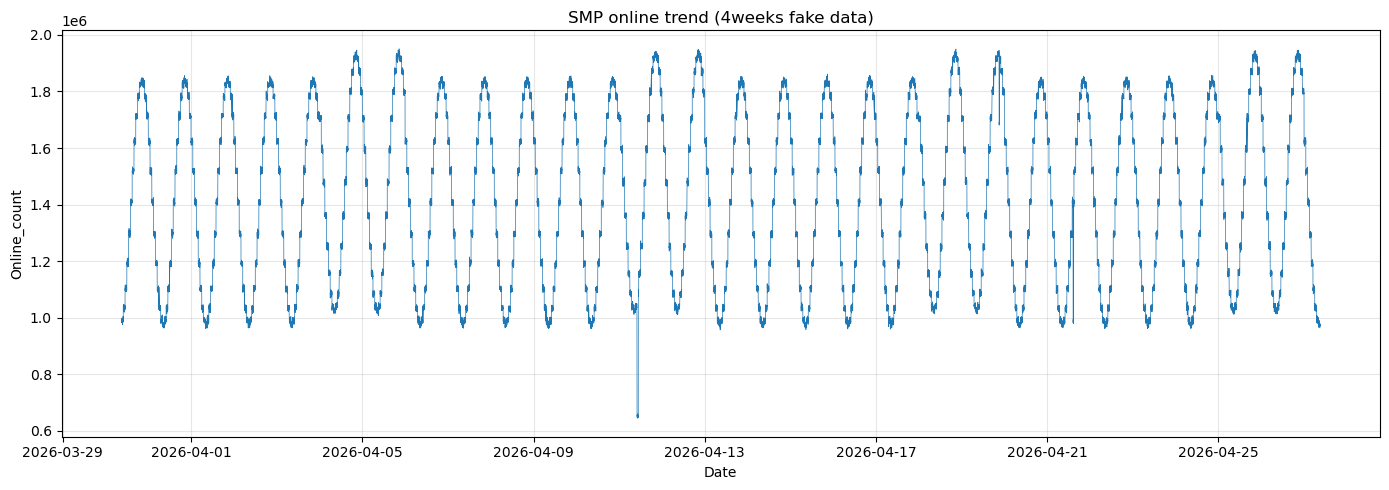

In [9]:
fig, ax = plt.subplots(figsize=(14,5)) 
ax.plot(df["timestamp"], df["online"], linewidth=0.5)
ax.set_xlabel("Date")
ax.set_ylabel("Online_count")
ax.set_title("SMP online trend (4weeks fake data)")
ax.grid(True, alpha=.3)
plt.tight_layout()
plt.show() 

In [10]:
# Filter: เฉพาะ จันทร์ 14:00 (4 สัปดาห์)
# mask = (df['timestamp'].dt.weekday == 0) & \
#        (df['timestamp'].dt.hour == 14) & \
#        (df['timestamp'].dt.minute == 0)

# mondays_14 = df[mask]
# print("Mondays at 14:00 (this is your baseline):")
# print(mondays_14[['timestamp', 'online']])

# baseline_values = mondays_14['online'].tolist()
# print(f"\nbaseline = {baseline_values}")

"""
2M boxes
calculate size of file 
clear file (how many day?) 
"""

'\n2M boxes\ncalculate size of file \nclear file (how many day?) \n'

In [11]:
def analyze (current, baseline) -> dict:
    # Edge case: baseline samples ไม่พอ 
    if ( len(baseline) < min_baseline_samples): 
        return {
            "level": level_warmup,
            "z_score": None,
            "pct": None,
            "abs_diff":None,
            "mean": None,
            "stdev": None,
            "direction": None,
            "reason": f"need >= {min_baseline_samples} samples, got {len(baseline)} "
        }

    u = mean(baseline)
    s = stdev(baseline,u) 
    diff = current - u 
    abs_diff = abs(diff)
    pct = (diff / u*100) if u > 0 else 0 
    
    # Edge case: stdev = 0 (ทุก baseline เท่ากันหมด) 
    if (s == 0):
        if (current ==u):
            return {
                "level": level_ok,
                "z_score": None,
                "pct": 0,
                "abs_diff":0,
                "mean":u,
                "stdev":0,
                "reason": "exact match (zero variance)"
            }
        return {
                "level": level_unknown,
                "z_score": None,
                "pct": pct,
                "abs_diff":abs_diff,
                "mean":u,
                "stdev":0,
                "reason": "zero variance, current differs"
            }
    # Spike: just info
    z = diff / s 
    abs_z = abs(z) 
    direction = "drop" if z < 0 else "spike"
    abs_pct = abs(pct) 
    if (direction == "spile"):
        if (abs_z <= warn_z):
            level = level_ok 
        else:
            level = level_info
        reason = f"z={z:+.2f} pct={pct:+.1f}% diff={diff:+,.0f}"
        return {
            "level": level,
            "z_score": z,
            "pct": pct,
            "abs_diff": abs_diff,
            "mean": u,
            "stdev": s,
            "reason": reason,
        }

    is_critical = (abs_z > crit_z) and (abs_pct > crit_pct) and (abs_diff > crit_abs)
    is_warning  = (abs_z > warn_z) and (abs_pct > warn_pct) and (abs_diff > warn_abs)

    if is_critical:
        level = level_critical
    elif is_warning:
        level = level_warning
    else:
        level = level_ok

    reason = f"z={z:+.2f} pct={pct:+.1f}% diff={diff:+,.0f}"
    return {"level": level,
            "z_score": z,
            "pct": pct,
            "abs_diff": abs_diff,            
            "mean": u,
            "stdev": s,
            "reason": reason
           }

In [12]:
# test_cases = [
#     ("Normal all good"   ,    1_510_000, baseline_values),
#     ("Normal day",            1_410_000, baseline_values),
#     ("Slight drop -1.4%",     1_390_000, baseline_values),
#     ("Drop -3%",              1_365_000, baseline_values),
#     ("Drop -7%",              1_310_000, baseline_values),  
#     ("Anomaly 2 (-12%)",      1_240_000, baseline_values),
#     ("Anomaly 1 (-30%)",        990_000, baseline_values),
#     ("System down",                   0, baseline_values),
# ]
# for name, current, base in test_cases:
#     result = analyze(current, base)
#     print(f"{name:<30} {current:>10,} {result['level']:>10} {result['reason']}")

In [13]:
def check_now(df, now):
    current_rows = df[df['timestamp'] == now]
    if (len(current_rows) == 0):
        return {
            "level": "ERROR",
            "reason": f"no data at {now}",
        }
    current = int(current_rows.iloc[0]['online'])

    baseline = get_baseline(df, now)

    result = analyze(current, baseline)

    result['timestamp'] = now 
    result['current'] = current
    result['baseline_n'] = len(baseline)
    return result 
    
r = check_now(df, pd.Timestamp('2026-04-27 08:30:00'))
print(r)

{'level': 'OK', 'z_score': 0.011033762112186235, 'pct': 0.00685504936061008, 'abs_diff': 66.92934782605153, 'mean': 976351.070652174, 'stdev': 6065.8683, 'reason': 'z=+0.01 pct=+0.0% diff=+67', 'timestamp': Timestamp('2026-04-27 08:30:00'), 'current': 976418, 'baseline_n': 184}


In [14]:
scenarios = [
    ("Normal moment",        pd.Timestamp('2026-04-27 08:30:00')),  # จันทร์ ก่อน anomaly
    ("During anomaly 1",     pd.Timestamp('2026-04-21 14:35:00')),  # อังคาร 14:35 (ตอน drop)
    ("During anomaly 2",     pd.Timestamp('2026-04-19 21:05:00')),  # อาทิตย์ 21:05
    ("During anomaly 3",     pd.Timestamp('2026-04-11 10:20:00')),  # เสาร์ 10:20
    ("Recovery moment",      pd.Timestamp('2026-04-21 14:55:00')),  # หลัง anomaly 1 จบ
]

print(f"{'Scenario':<22} {'Time':<22} {'Current':>11} {'Baseline n':>11} {'Level':>10}  Reason")
print("-" * 110)
for name, ts in scenarios:
    r = check_now(df, ts)
    print(f"{name:<22} {str(ts):<22} {r['current']:>11,} {r['baseline_n']:>11} "
          f"{r['level']:>10}  {r.get('reason', '')}")

Scenario               Time                       Current  Baseline n      Level  Reason
--------------------------------------------------------------------------------------------------------------
Normal moment          2026-04-27 08:30:00        976,418         184         OK  z=+0.01 pct=+0.0% diff=+67
During anomaly 1       2026-04-21 14:35:00        986,767         183   CRITICAL  z=-12.96 pct=-30.5% diff=-432,167
During anomaly 2       2026-04-19 21:05:00      1,681,833         183   CRITICAL  z=-23.10 pct=-12.5% diff=-240,879
During anomaly 3       2026-04-11 10:20:00        651,128         183   CRITICAL  z=-24.55 pct=-39.6% diff=-426,336
Recovery moment        2026-04-21 14:55:00      1,417,403         183         OK  z=-0.69 pct=-2.6% diff=-38,571
